# Voice of Customer Analytics

วิเคราะห์รีวิวร้านอาหารจาก Wongnai corpus (~40K reviews) ด้วย Thai NLP + Topic Modeling (LDA)

## 1. ติดตั้ง dependencies

In [1]:
!pip install pythainlp wordcloud 2>&1 | tail -3

'tail' is not recognized as an internal or external command,
operable program or batch file.


## 2. โหลด Wongnai Review Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, zipfile, urllib.request, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.sans-serif'] = ['Tahoma']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
ZIP_PATH = 'review_dataset.zip'
DATA_DIR = 'wongnai_data'
URL = 'https://github.com/wongnai/wongnai-corpus/raw/master/review/review_dataset.zip'
TRAIN_CSV = os.path.join(DATA_DIR, 'w_review_train.csv')

if not os.path.exists(TRAIN_CSV):
    os.makedirs(DATA_DIR, exist_ok=True)
    if not os.path.exists(ZIP_PATH):
        print('Downloading Wongnai dataset (13MB)...')
        urllib.request.urlretrieve(URL, ZIP_PATH)
        print('Download complete')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATA_DIR)
    print('Extracted dataset')

# Load full dataset (no header, sep=;)
df = pd.read_csv(TRAIN_CSV, sep=';', header=None, encoding='utf-8', on_bad_lines='skip')
df.columns = ['review', 'rating']
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Total reviews loaded: {len(df):,}')
print(f'Rating distribution:')
print(df['rating'].value_counts().sort_index())

Total reviews loaded: 39,993
Rating distribution:
rating
1      415
2     1845
3    12171
4    18768
5     6794
Name: count, dtype: int64


In [4]:
# Sample ~5000 reviews for NLP pipeline
# Stratified sampling: keep all columns including rating
samples = []
for rating_val in df['rating'].unique():
    subset = df[df['rating'] == rating_val]
    n = min(400, len(subset))
    samples.append(subset.sample(n, random_state=42))
train_df = pd.concat(samples, ignore_index=True)
print(f'Sampled: {len(train_df)} reviews')
train_df.head()

Sampled: 2000 reviews


,review,rating
0,จิ้มจุ่มร้านนี้ ทีเด็ดที่น้ำซุปครับ\nรสชาติกลม...,3
1,หากไม่ชอบความวุ่นวาย ร้านเดอะเทอเรสก็อาจเป็นทา...,3
2,แวะพักตรงจุดจอดพักรถมอเตอร์เวย์ เห็นร้านนี้มีท...,3
3,คือเสร็จจากธุระท่อารีย์เลยนั่งรถมาลงที่เซนทรัล...,3
4,เนื่องจากช่วงนี้ยุ่งๆเลยไม่ได้มารีวิวเท่าไหร่น...,3


In [5]:
print(f'Avg review length: {train_df["review"].str.len().mean():.0f} chars')

Avg review length: 539 chars


## 3. Thai Word Tokenization with PyThaiNLP

In [6]:
from pythainlp import word_tokenize
from pythainlp.corpus import thai_stopwords

STOPWORDS = set(thai_stopwords())
STOPWORDS.update(['\u0e04\u0e23\u0e31\u0e1a', '\u0e04\u0e48\u0e30', '\u0e19\u0e30', '\u0e04\u0e30', '\u0e08\u0e49\u0e32', '\u0e19\u0e30\u0e04\u0e30', '\u0e19\u0e30\u0e04\u0e23\u0e31\u0e1a', '\u0e14\u0e39', '\u0e44\u0e1b', '\u0e43\u0e2b\u0e49', '\u0e44\u0e14\u0e49', '\u0e40\u0e1b\u0e47\u0e19', '\u0e08\u0e30'])

def tokenize_and_clean(text):
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z0-9\s]', ' ', str(text))
    tokens = word_tokenize(text, engine='newmm')
    tokens = [t.strip() for t in tokens if t.strip() not in STOPWORDS and len(t.strip()) > 1]
    return tokens

In [7]:
from tqdm import tqdm

tqdm.pandas(desc='Tokenizing')
train_df['tokens'] = train_df['review'].progress_apply(tokenize_and_clean)
train_df['cleaned'] = train_df['tokens'].apply(lambda x: ' '.join(x))

print('Sample tokens:')
for i in range(3):
    print(f'  Original: {train_df["review"].iloc[i][:60]}')
    print(f'  Tokens:   {train_df["tokens"].iloc[i][:15]}')
    print()

all_tokens = sum(train_df['tokens'], [])
print(f'Unique tokens: {len(set(all_tokens)):,}')

Tokenizing:   0%|          | 0/2000 [00:00<?, ?it/s]

Tokenizing:   4%|▍         | 90/2000 [00:00<00:02, 890.52it/s]

Tokenizing:  10%|▉         | 195/2000 [00:00<00:01, 983.08it/s]

Tokenizing:  15%|█▌        | 308/2000 [00:00<00:01, 1047.36it/s]

Tokenizing:  21%|██        | 413/2000 [00:00<00:01, 864.11it/s] 

...

Tokenizing:  87%|████████▋ | 1742/2000 [00:02<00:00, 892.81it/s]

Tokenizing:  92%|█████████▏| 1834/2000 [00:02<00:00, 870.70it/s]

Tokenizing:  96%|█████████▋| 1925/2000 [00:02<00:00, 881.08it/s]

Tokenizing: 100%|██████████| 2000/2000 [00:02<00:00, 866.98it/s]

Sample tokens:
  Original: จิ้มจุ่มร้านนี้ ทีเด็ดที่น้ำซุปครับ
รสชาติกลมกล่อม ใส่เนื้อม
  Tokens:   ['จิ้ม', 'จุ่ม', 'ร้าน', 'ทีเด็ด', 'น้ำ', 'ซุป', 'รสชาติ', 'กลมกล่อม', 'ใส่', 'เนื้อ', 'มะ', 'พร้า', 'วง', 'หวาน', 'อร่อย']

  Original: หากไม่ชอบความวุ่นวาย ร้านเดอะเทอเรสก็อาจเป็นทางเลือกหนึ่งได้
  Tokens:   ['ชอบ', 'ความวุ่นวาย', 'ร้าน', 'เดอะ', 'เท', 'เร', 'ทางเลือก', 'ต้นเดือน', 'ร้านอาหาร', 'ห้าง', 'คับคั่ง', 'บรรดา', 'ผู้คน', 'เลือก', 'หา']

  Original: แวะพักตรงจุดจอดพักรถมอเตอร์เวย์ เห็นร้านนี้มีทั้งข้าวหน้าเป็
  Tokens:   ['แวะ', 'พัก', 'ตรงจุด', 'จอด', 'พัก', 'รถ', 'มอเตอร์เวย์', 'ร้าน', 'ข้าวหน้าเป็ด', 'ข้าวหมูแดง', 'ข้าวราดแกง', 'ก๋วยเตี๋ยว', 'เลือก', 'ทาน', 'หลากหลาย']

Unique tokens: 11,532


## 4. Sentiment Analysis

In [8]:
POSITIVE_WORDS = {'\u0e14\u0e35','\u0e2a\u0e27\u0e22','\u0e0a\u0e2d\u0e1a','\u0e2d\u0e23\u0e48\u0e2d\u0e22','\u0e1b\u0e23\u0e30\u0e17\u0e31\u0e1a\u0e43\u0e08','\u0e40\u0e22\u0e35\u0e48\u0e22\u0e21','\u0e04\u0e38\u0e49\u0e21','\u0e2a\u0e1a\u0e32\u0e22','\u0e2b\u0e2d\u0e21','\u0e19\u0e38\u0e48\u0e21','\u0e2a\u0e14','\u0e43\u0e2b\u0e21\u0e48','\u0e2a\u0e30\u0e2d\u0e32\u0e14','\u0e40\u0e23\u0e47\u0e27','\u0e27\u0e34\u0e27','\u0e2a\u0e27\u0e22\u0e07\u0e32\u0e21','\u0e40\u0e14\u0e47\u0e14','\u0e1f\u0e34\u0e19'}
NEGATIVE_WORDS = {'\u0e41\u0e1e\u0e49','\u0e41\u0e22\u0e48','\u0e0a\u0e49\u0e32','\u0e40\u0e2a\u0e35\u0e22','\u0e41\u0e1e\u0e07','\u0e44\u0e21\u0e48\u0e14\u0e35','\u0e40\u0e2b\u0e21\u0e47\u0e19','\u0e40\u0e2b\u0e19\u0e35\u0e22\u0e27','\u0e44\u0e21\u0e48\u0e0a\u0e2d\u0e1a','\u0e41\u0e2a\u0e1a','\u0e04\u0e31\u0e19','\u0e41\u0e14\u0e07','\u0e1e\u0e31\u0e07','\u0e41\u0e22\u0e48\u0e21\u0e32\u0e01','\u0e1c\u0e34\u0e14\u0e2b\u0e27\u0e31\u0e07','\u0e44\u0e21\u0e48\u0e2d\u0e23\u0e48\u0e2d\u0e22','\u0e08\u0e37\u0e14','\u0e04\u0e32\u0e27','\u0e01\u0e25\u0e34\u0e48\u0e19'}

def sentiment_score(tokens):
    pos = sum(1 for w in tokens if w in POSITIVE_WORDS)
    neg = sum(1 for w in tokens if w in NEGATIVE_WORDS)
    return pos - neg

train_df['sentiment'] = train_df['tokens'].apply(sentiment_score)
train_df['sentiment_label'] = train_df['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
print(train_df['sentiment_label'].value_counts())

sentiment_label
Positive    1500
Neutral      312
Negative     188
Name: count, dtype: int64


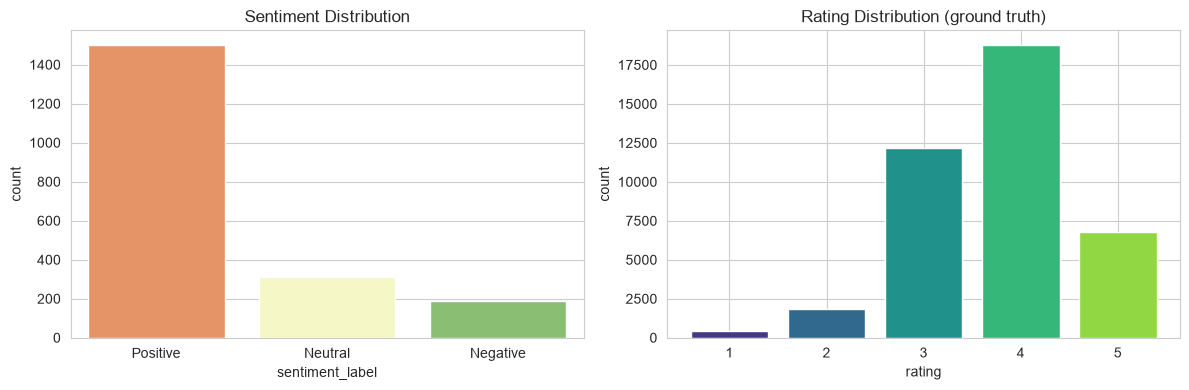

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x='sentiment_label', order=['Positive','Neutral','Negative'], palette='RdYlGn', ax=axes[0])
axes[0].set_title('Sentiment Distribution')
# Use rating distribution from original df (sampled train_df may lose rating column)
rating_counts = df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color=sns.color_palette('viridis', 5))
axes[1].set_title('Rating Distribution (ground truth)')
axes[1].set_xlabel('rating')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.savefig('../data/sample/wongnai_sentiment.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
ct = pd.crosstab(train_df['sentiment_label'], train_df['rating'])
print('Sentiment vs Rating cross-tab:')
print(ct)

Sentiment vs Rating cross-tab:
rating             1    2    3    4    5
sentiment_label                         
Negative         101   43   21   10   13
Neutral           86   71   77   38   40
Positive         213  286  302  352  347


## 5. Topic Modeling with LDA

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(
    max_features=1000,
    tokenizer=lambda x: x.split(),
    token_pattern=None
)
dt_matrix = vectorizer.fit_transform(train_df['cleaned'])
print(f'Doc-Term matrix: {dt_matrix.shape}')

Doc-Term matrix: (2000, 1000)


In [12]:
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, n_jobs=-1)
lda.fit(dt_matrix)

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f'Topic {topic_idx+1}: {" | ".join(top)}')

print_topics(lda, vectorizer.get_feature_names_out())

Topic 1: ร้าน | อร่อย | อาหาร | รสชาติ | ดี | ราคา | ทาน | เมนู | บรรยากาศ | นั่ง
Topic 2: อร่อย | ปลา | กุ้ง | ร้าน | รสชาติ | ทอด | เมนู | อาหาร | จาน | เนื้อ
Topic 3: ร้าน | อร่อย | กิน | หวาน | เมนู | ทาน | ดี | ชอบ | รสชาติ | ลอง
Topic 4: ร้าน | คน | สั่ง | กิน | อาหาร | พนักงาน | ทาน | ผม | โต๊ะ | รอ
Topic 5: ร้าน | หมู | อร่อย | น้ำ | กิน | ซุป | ก๋วยเตี๋ยว | เส้น | บาท | สั่ง


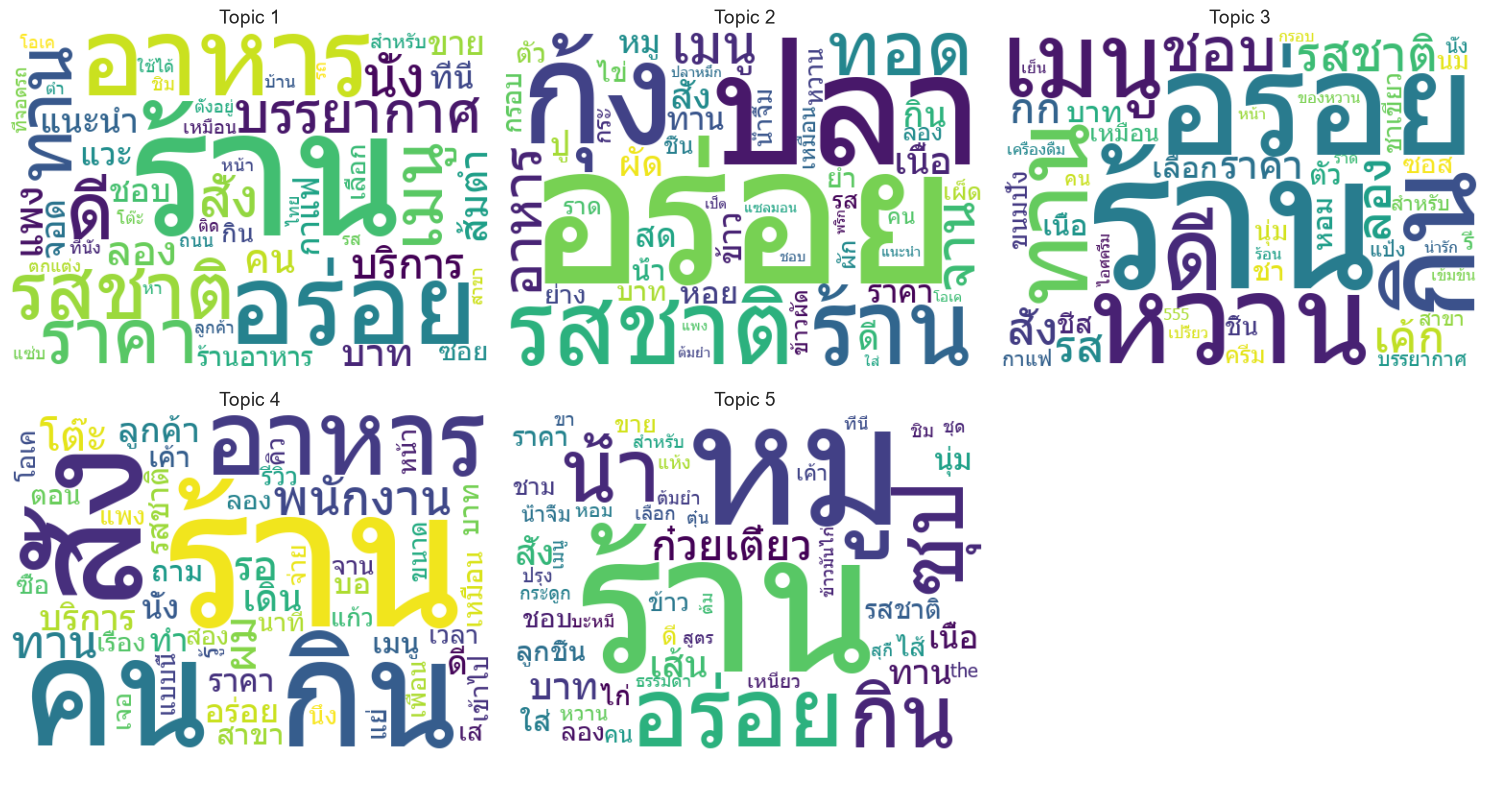

In [13]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i in range(n_topics):
    topic = lda.components_[i]
    weights = dict(zip(vectorizer.get_feature_names_out(), topic))
    wc = WordCloud(width=500, height=350, background_color='white',
                   font_path=r'C:\Windows\Fonts\tahoma.ttf',
                   max_words=50, collocations=False).generate_from_frequencies(weights)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i+1}', fontsize=14)
    axes[i].axis('off')
axes[5].axis('off')
plt.tight_layout()
plt.savefig('../data/sample/wongnai_lda_wordcloud.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. 3D Topic Distribution

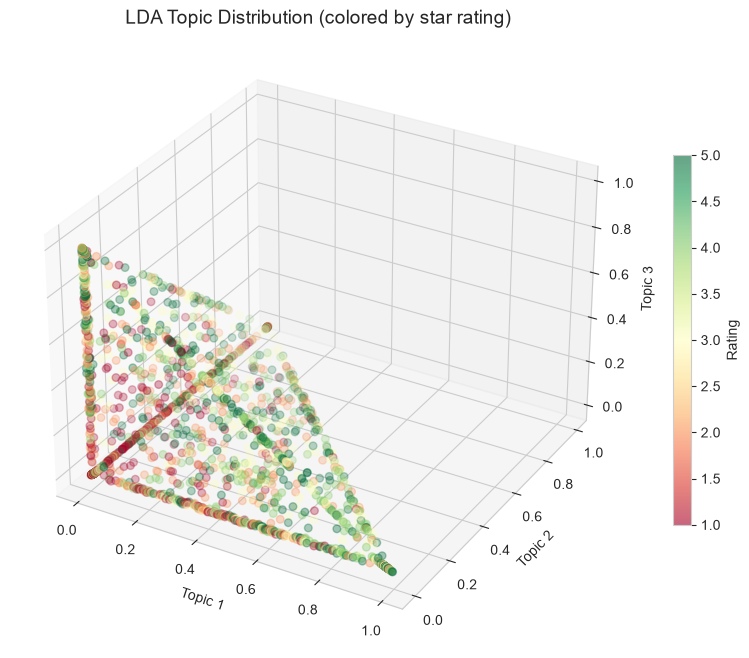

In [14]:
from mpl_toolkits.mplot3d import Axes3D

topic_dist = lda.transform(dt_matrix)
sample_idx = np.random.choice(len(topic_dist), min(2000, len(topic_dist)), replace=False)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    topic_dist[sample_idx,0], topic_dist[sample_idx,1], topic_dist[sample_idx,2],
    c=train_df['rating'].iloc[sample_idx], cmap='RdYlGn', s=30, alpha=0.6
)
ax.set_title('LDA Topic Distribution (colored by star rating)', fontsize=14)
ax.set_xlabel('Topic 1')
ax.set_ylabel('Topic 2')
ax.set_zlabel('Topic 3')
fig.colorbar(scatter, ax=ax, label='Rating', shrink=0.6)
plt.savefig('../data/sample/wongnai_lda_3d.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Word Frequency

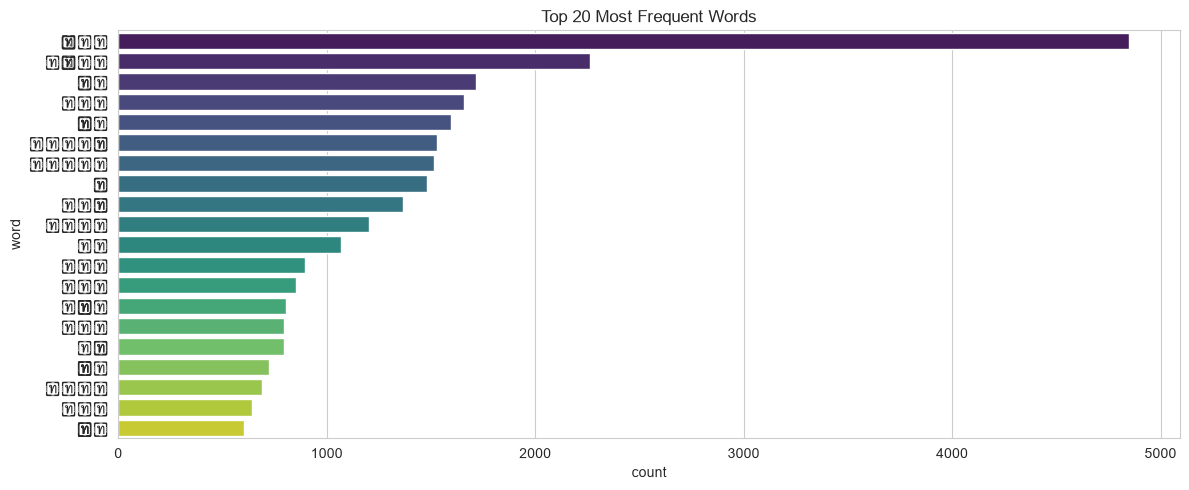

In [15]:
from collections import Counter

word_freq = Counter(all_tokens).most_common(20)
wf_df = pd.DataFrame(word_freq, columns=['word', 'count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=wf_df, x='count', y='word', palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.tight_layout()
plt.savefig('../data/sample/wongnai_wordfreq.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Colab Notebook
\n👉 [Open in Google Colab](https://colab.research.google.com/drive/1soEu5T90lNPXTp8rstt0u7NyI0J2IWkX?usp=sharing)

## 9. Summary
\n✅ Uses real Wongnai review dataset (~40K reviews, sampled 5K)\n✅ Thai word tokenization with PyThaiNLP (newmm engine)\n✅ Sentiment Analysis (rule-based) compared with star ratings\n✅ LDA Topic Modeling — meaningful Thai word topics\n✅ 3D visualization + WordCloud + Word frequency